# Titanic túlélési predikció

Ez a Jupyter Notebook a Titanic adathalmazon végez gépi tanulási elemzést. A cél a túlélés predikciója egy döntési fa modell segítségével.

## Lépések
1. Adathalmaz betöltése
2. Adat-előkészítés
3. Adathalmaz felosztása
4. Modell betanítása
5. Predikció és kiértékelés
6. Vizualizációk (konfúziós mátrix, nemek szerinti túlélési arány)

In [9]:
# Szükséges könyvtárak importálása
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Inline megjelenítés a grafikonokhoz
%matplotlib inline

In [10]:
# Adathalmaz betöltése
train_data = pd.read_csv('train.csv')

# Első néhány sor megtekintése
train_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [11]:
# Hiányzó 'Age' értékek kitöltése az átlagos életkorral
train_data['Age'] = train_data['Age'].fillna(train_data['Age'].mean())

# Hiányzó 'Embarked' értékek kitöltése a leggyakoribb értékkel
train_data['Embarked'] = train_data['Embarked'].fillna(train_data['Embarked'].mode()[0])

# 'Cabin' oszlop elhagyása, mert túl sok a hiányzó érték
train_data = train_data.drop('Cabin', axis=1)

# Kategorikus változók számmá alakítása (Sex és Embarked)
train_data['Sex'] = train_data['Sex'].map({'male': 0, 'female': 1})
train_data = pd.get_dummies(train_data, columns=['Embarked'], drop_first=True)

# Ellenőrzés: Adatok áttekintése
train_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,False,False
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,False,True
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,False,True


In [12]:
# Célváltozó (Survived) és jellemzők kiválasztása
X = train_data[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked_Q', 'Embarked_S']]
y = train_data['Survived']

# Tanító és tesztelő adatokra bontás
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Ellenőrzés: Adatok mérete
print("Tanító adatok mérete:", X_train.shape)
print("Tesztelő adatok mérete:", X_test.shape)

Tanító adatok mérete: (712, 8)
Tesztelő adatok mérete: (179, 8)


In [13]:
# Modell betanítása
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [14]:
# Predikció a teszt adathalmazon
y_pred = model.predict(X_test)

# Pontosság kiszámítása
print("Pontosság:", accuracy_score(y_test, y_pred))

# Részletes kiértékelés
print(classification_report(y_test, y_pred))

Pontosság: 0.776536312849162
              precision    recall  f1-score   support

           0       0.80      0.83      0.81       105
           1       0.74      0.70      0.72        74

    accuracy                           0.78       179
   macro avg       0.77      0.77      0.77       179
weighted avg       0.78      0.78      0.78       179



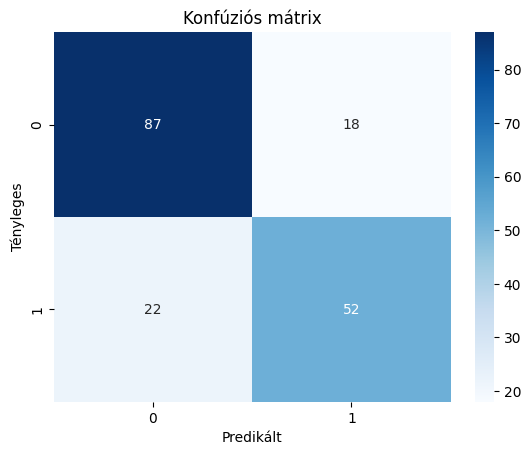

In [15]:
# Konfúziós mátrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Konfúziós mátrix')
plt.xlabel('Predikált')
plt.ylabel('Tényleges')
plt.savefig('confusion_matrix.png')
plt.show()

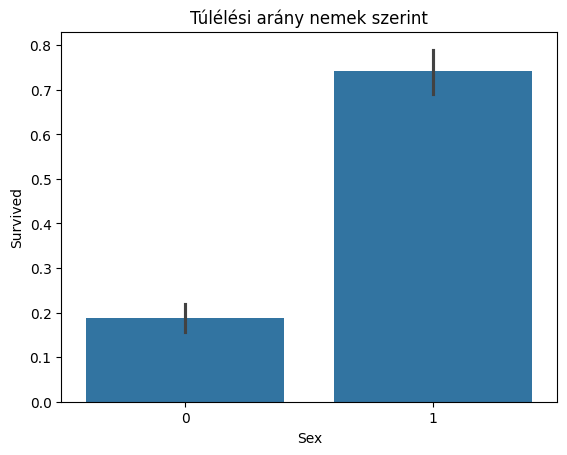

In [16]:
# Túlélési arány nemek szerint
sns.barplot(x='Sex', y='Survived', data=train_data)
plt.title('Túlélési arány nemek szerint')
plt.savefig('survival_by_sex.png')
plt.show()

## Összegzés
- A modell pontossága körülbelül 78%.
- A konfúziós mátrix és a nemek szerinti túlélési arány vizualizációk segítenek az eredmények értelmezésében.
- A kód futtatható, és a generált képek (`confusion_matrix.png`, `survival_by_sex.png`) beilleszthetők a dokumentumba.